# 01 - Exploratory data analysis

Objective:
- inspect the assembled NHANES sleep dataset
- understand the target variable and missingness structure
- assess feature quality and interpretability
- identify variables requiring recoding, exclusion, or later review before modeling
- prepare a clean handoff from EDA to MARS configuration

## 0. Imports and setup

This section loads the core libraries used for exploratory analysis.

The goal is to keep the setup compact and sufficient for:
- structural inspection
- summary statistics
- missingness analysis
- basic plotting
- early analytical reasoning

In [1]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

## 1. Load the assembled dataset

This section loads the assembled NHANES sleep master dataset created in the previous notebook.

At this stage, the goal is not to rebuild the dataset, but to begin understanding its structure and analytical usability.

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

master_path = PROCESSED_DIR / "nhanes_sleep_master_v1.csv"
df = pd.read_csv(master_path)

print(PROJECT_ROOT)
print(master_path)

F:\DOCUMENTOS\CIENCIA DE DATOS\portfolio-data-science\morpheus-sleep-health-ml
F:\DOCUMENTOS\CIENCIA DE DATOS\portfolio-data-science\morpheus-sleep-health-ml\data\processed\nhanes_sleep_master_v1.csv


In [3]:
df.head()

,participant_id,sleep_hours_weekday,sleep_hours_weekend,trouble_sleeping,told_doctor_trouble_sleeping,told_doctor_sleep_disorder,snoring_frequency,sex,age_years,race_ethnicity,...,phq_sleep_problems,phq_low_energy,phq_appetite_problems,phq_feeling_bad_about_self,phq_trouble_concentrating,phq_slow_or_restless,phq_self_harm_thoughts,short_sleep,systolic_bp_mean,diastolic_bp_mean
0,109266.0,7.5,8.0,1.0,NaN,2.0,NaN,2.0,29.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,54.333333
1,109267.0,8.0,8.0,NaN,NaN,2.0,2.0,2.0,21.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,109268.0,8.5,8.0,NaN,NaN,2.0,1.0,2.0,18.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
3,109271.0,10.0,13.0,NaN,NaN,1.0,3.0,1.0,49.0,3.0,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,0.0,107.000000,67.000000
4,109273.0,6.5,8.0,NaN,NaN,1.0,2.0,1.0,36.0,3.0,...,2.0,2.0,2.0,2.0,2.0,1.0,NaN,1.0,113.666667,67.333333


## 2. Structural overview

This section performs a first structural inspection of the dataset.

The aim is to answer a few basic questions before deeper exploration:
- how large is the dataset?
- what variables are available?
- what data types do they have?
- does the loaded file match the expected assembly output?

In [4]:
df.shape

(10195, 47)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10195 entries, 0 to 10194
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   participant_id                  10195 non-null  float64
 1   sleep_hours_weekday             7288 non-null   float64
 2   sleep_hours_weekend             7109 non-null   float64
 3   trouble_sleeping                6675 non-null   float64
 4   told_doctor_trouble_sleeping    2244 non-null   float64
 5   told_doctor_sleep_disorder      10187 non-null  float64
 6   snoring_frequency               8395 non-null   float64
 7   sex                             10195 non-null  float64
 8   age_years                       10195 non-null  float64
 9   race_ethnicity                  10195 non-null  float64
 10  education_level                 9217 non-null   float64
 11  income_to_poverty_ratio         8577 non-null   float64
 12  weight_kg                       9285 non-nu

In [6]:
df.columns.tolist()

['participant_id',
 'sleep_hours_weekday',
 'sleep_hours_weekend',
 'trouble_sleeping',
 'told_doctor_trouble_sleeping',
 'told_doctor_sleep_disorder',
 'snoring_frequency',
 'sex',
 'age_years',
 'race_ethnicity',
 'education_level',
 'income_to_poverty_ratio',
 'weight_kg',
 'height_cm',
 'body_mass_index',
 'waist_circumference_cm',
 'systolic_bp_1',
 'diastolic_bp_1',
 'systolic_bp_2',
 'diastolic_bp_2',
 'systolic_bp_3',
 'diastolic_bp_3',
 'smoked_100_cigarettes_lifetime',
 'current_smoking_frequency',
 'alcohol_lifetime_12_drinks',
 'alcohol_past_year_12_drinks',
 'alcohol_frequency',
 'drinks_per_day',
 'vigorous_activity',
 'vigorous_activity_days',
 'vigorous_activity_minutes',
 'moderate_activity',
 'moderate_activity_days',
 'moderate_activity_minutes',
 'sedentary_minutes',
 'phq_little_interest',
 'phq_feeling_down',
 'phq_sleep_problems',
 'phq_low_energy',
 'phq_appetite_problems',
 'phq_feeling_bad_about_self',
 'phq_trouble_concentrating',
 'phq_slow_or_restless',
 'p

## 3. Analytical framing

This EDA does not start from a raw dataset. It starts from an assembled master dataset.

Therefore, the purpose of this notebook is not to rebuild structure, but to assess whether the assembled dataset is analytically ready.

The main questions are:
- how usable is the target?
- how much missingness remains?
- which variables look reliable and interpretable?
- which variables may later require recoding, exclusion, or leakage review?

## 4. Target overview

This section inspects the main target variable, `short_sleep`.

The purpose is to verify:
- how many participants are usable for supervised modeling
- how much target missingness remains
- whether the class balance looks reasonable for a first modeling baseline

In [7]:
df["short_sleep"].value_counts(dropna=False)

short_sleep
0.0    4804
NaN    2907
1.0    2484
Name: count, dtype: int64

In [8]:
df["short_sleep"].value_counts(normalize=True, dropna=False)

short_sleep
0.0    0.471211
NaN    0.285140
1.0    0.243649
Name: proportion, dtype: float64

In [9]:
df["short_sleep"].isna().mean()

np.float64(0.2851397743992153)

In [10]:
df[["sleep_hours_weekday", "short_sleep"]].head(10)

,sleep_hours_weekday,short_sleep
0,7.5,0.0
1,8.0,0.0
2,8.5,0.0
3,10.0,0.0
4,6.5,1.0
5,9.5,0.0
6,NaN,NaN
7,NaN,NaN
8,9.5,0.0
9,8.0,0.0


In [11]:
target_availability = pd.DataFrame({
    "count": [
        len(df),
        df["short_sleep"].notna().sum(),
        df["short_sleep"].isna().sum(),
    ],
    "proportion": [
        1.0,
        df["short_sleep"].notna().mean(),
        df["short_sleep"].isna().mean(),
    ]
}, index=[
    "full_assembled_cohort",
    "modelable_cohort",
    "target_missing_cohort",
])

target_availability

,count,proportion
full_assembled_cohort,10195,1.00000
modelable_cohort,7288,0.71486
target_missing_cohort,2907,0.28514


In [12]:
(
    df["sleep_hours_weekday"].isna() & df["short_sleep"].notna()
).sum(), (
    df["sleep_hours_weekday"].notna() & df["short_sleep"].isna()
).sum()

(np.int64(0), np.int64(0))

## 5. Why target missingness matters

The assembled dataset and the modeling-ready dataset are not the same object.

The assembled dataset preserves the broader sleep cohort, but supervised modeling will only be possible on participants with a defined `short_sleep` target.

For that reason, later EDA steps will distinguish between:
- the full assembled dataset
- the target-available subset

## 6. Missingness overview

This section inspects missing values across the dataset.

The purpose is not only to quantify missingness, but also to identify which variables may become problematic for:
- interpretability
- preprocessing
- feature retention
- later modeling decisions

In [13]:
missing_full = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .to_frame()
)

missing_full.head(20)

,missing_pct
phq_self_harm_thoughts,96.86
phq_slow_or_restless,91.42
phq_feeling_bad_about_self,86.13
phq_trouble_concentrating,85.90
drinks_per_day,82.47
phq_feeling_down,79.28
phq_little_interest,79.09
phq_appetite_problems,79.07
vigorous_activity_days,78.91
told_doctor_trouble_sleeping,77.99


In [14]:
missing_full[missing_full["missing_pct"] > 0]

,missing_pct
phq_self_harm_thoughts,96.86
phq_slow_or_restless,91.42
phq_feeling_bad_about_self,86.13
phq_trouble_concentrating,85.90
drinks_per_day,82.47
phq_feeling_down,79.28
phq_little_interest,79.09
phq_appetite_problems,79.07
vigorous_activity_days,78.91
told_doctor_trouble_sleeping,77.99


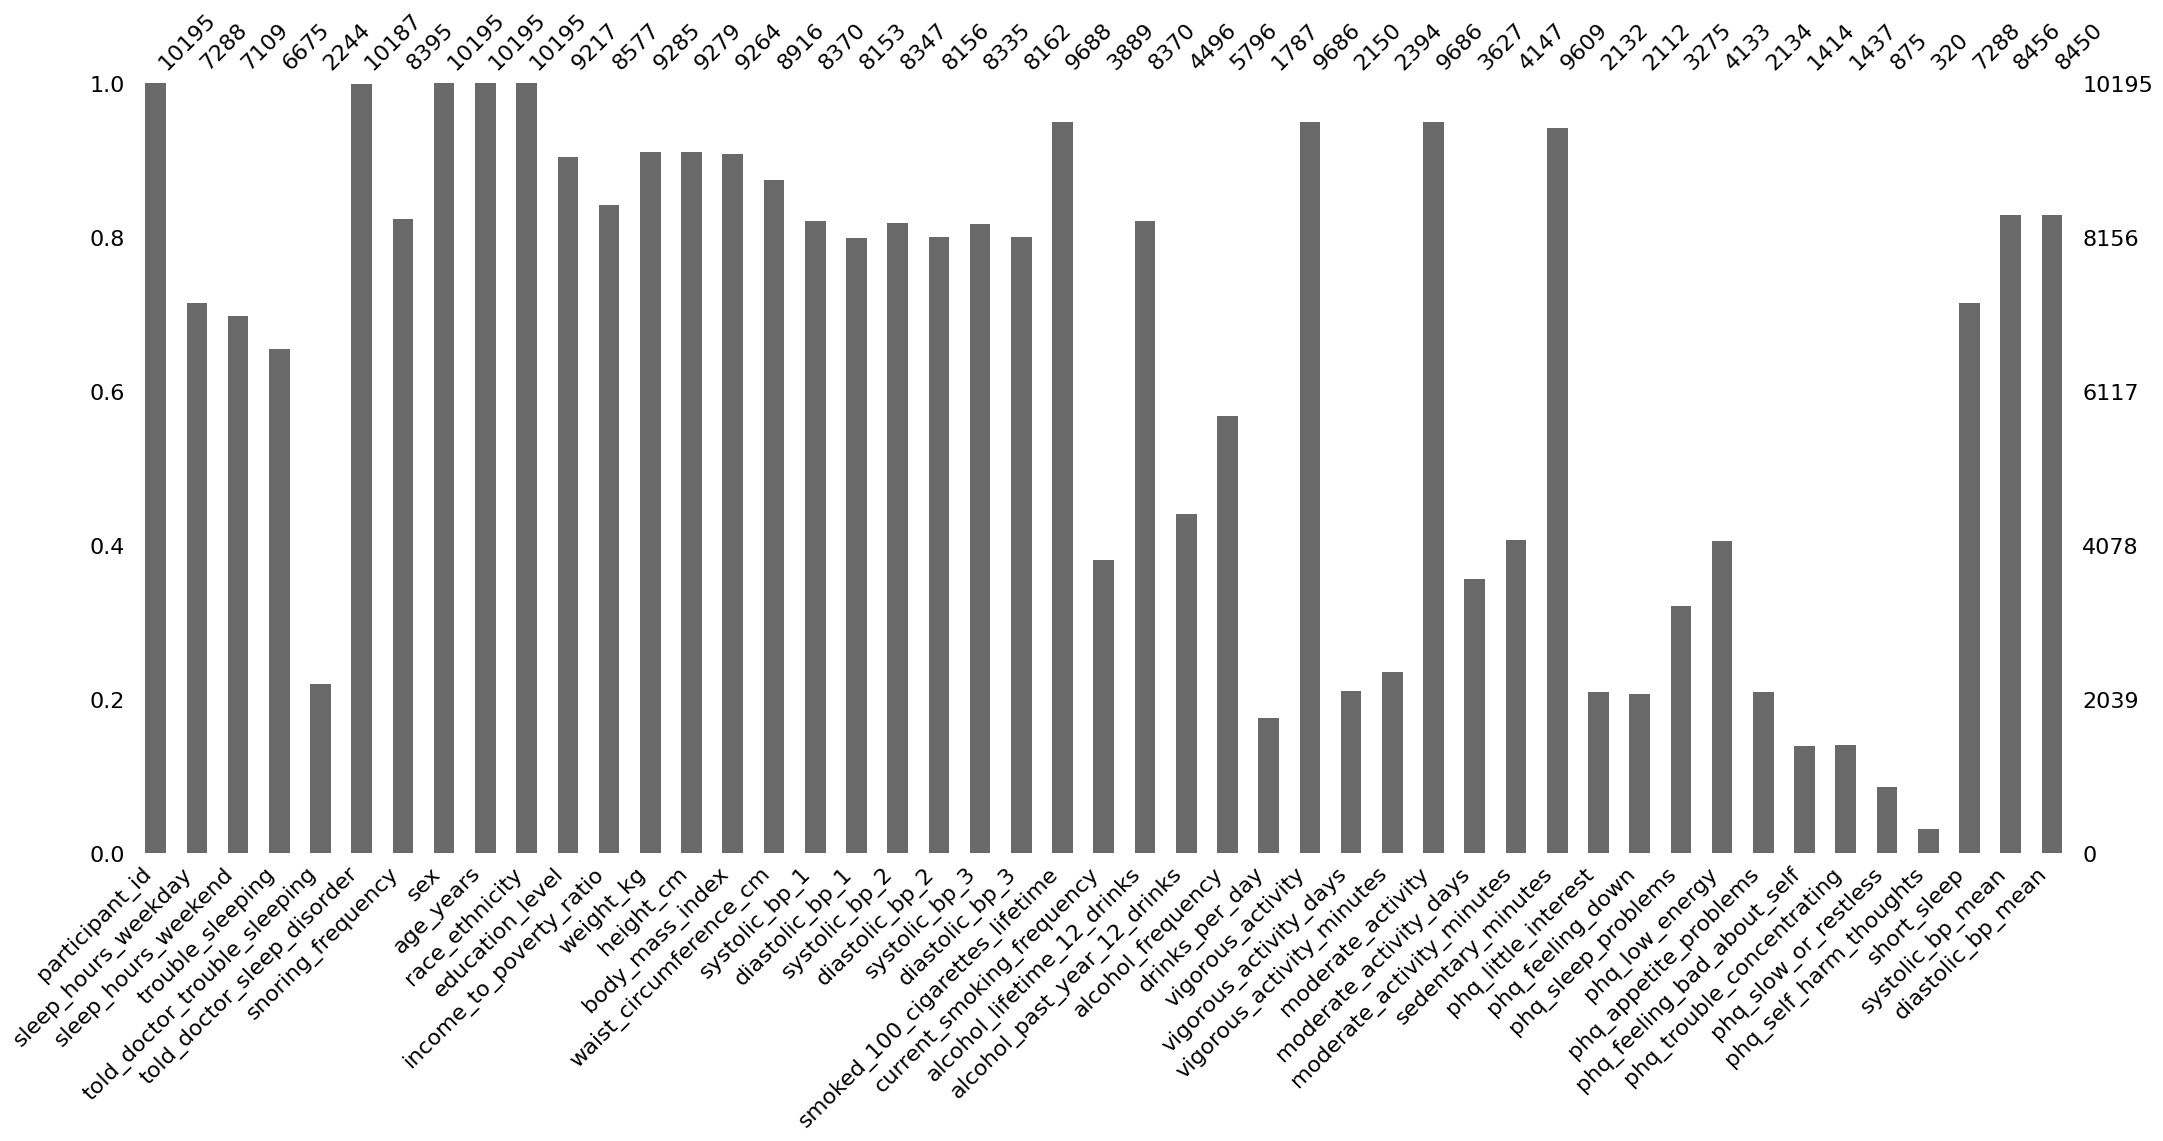

In [15]:
msno.bar(df)
plt.show()

## 7. Missingness in the modelable subset

This section examines missingness within the subset with available target values (`df_modelable`), which is the relevant cohort for modeling.

In [16]:
df_modelable = df[df["short_sleep"].notna()].copy()

missing_modelable = (
    df_modelable.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .to_frame()
)

missing_modelable.head(20)

,missing_pct
phq_self_harm_thoughts,96.89
phq_slow_or_restless,91.36
phq_feeling_bad_about_self,85.96
phq_trouble_concentrating,85.87
drinks_per_day,82.49
phq_little_interest,78.92
phq_feeling_down,78.88
phq_appetite_problems,78.84
vigorous_activity_days,78.75
told_doctor_trouble_sleeping,77.65


In [17]:
missing_full_series = (
    missing_full["missing_pct"] if isinstance(missing_full, pd.DataFrame) else missing_full
)

missing_modelable_series = (
    missing_modelable["missing_pct"] if isinstance(missing_modelable, pd.DataFrame) else missing_modelable
)

missing_comparison = pd.concat(
    [
        missing_full_series.rename("missing_rate_full_pct"),
        missing_modelable_series.rename("missing_rate_modelable_pct"),
    ],
    axis=1,
)

missing_comparison["delta_modelable_minus_full_pct"] = (
    missing_comparison["missing_rate_modelable_pct"]
    - missing_comparison["missing_rate_full_pct"]
)

comparison_exclusions = ["short_sleep", "sleep_hours_weekday", "participant_id"]

missing_comparison = missing_comparison.drop(
    index=[col for col in comparison_exclusions if col in missing_comparison.index]
)

missing_comparison.sort_values("delta_modelable_minus_full_pct")

,missing_rate_full_pct,missing_rate_modelable_pct,delta_modelable_minus_full_pct
sleep_hours_weekend,30.27,21.76,-8.51
snoring_frequency,17.66,17.00,-0.66
diastolic_bp_3,19.94,19.39,-0.55
systolic_bp_3,18.24,17.71,-0.53
diastolic_bp_2,20.00,19.53,-0.47
phq_sleep_problems,67.88,67.44,-0.44
systolic_bp_1,17.90,17.49,-0.41
phq_feeling_down,79.28,78.88,-0.40
systolic_bp_mean,17.06,16.66,-0.40
diastolic_bp_mean,17.12,16.73,-0.39


The missingness structure in the modelable subset remains broadly similar to that of the full assembled cohort. For most variables, the difference in missingness between `df` and `df_modelable` is small in absolute terms, which suggests that restricting the analysis to participants with an observed target does not materially distort the overall data availability profile.

The clearest exception is `sleep_hours_weekend`, whose missingness decreases from 30.27% in the full cohort to 21.76% in the modelable subset. This is analytically plausible: participants with valid weekday sleep information also appear more likely to report weekend sleep duration.

A few variables show slightly higher missingness in the modelable cohort, but these increases are modest and do not indicate a fundamentally different missingness regime. Overall, `df_modelable` appears suitable as the operational cohort for preprocessing and modeling, while variable-level missingness should still be considered explicitly in downstream decisions.The missingness structure in the modelable subset remains broadly similar to that of the full assembled cohort. For most variables, the difference in missingness between `df` and `df_modelable` is small in absolute terms, which suggests that restricting the analysis to participants with an observed target does not materially distort the overall data availability profile.

The clearest exception is `sleep_hours_weekend`, whose missingness decreases from 30.27% in the full cohort to 21.76% in the modelable subset. This is analytically plausible: participants with valid weekday sleep information also appear more likely to report weekend sleep duration.

A few variables show slightly higher missingness in the modelable cohort, but these increases are modest and do not indicate a fundamentally different missingness regime. Overall, `df_modelable` appears suitable as the operational cohort for preprocessing and modeling, while variable-level missingness should still be considered explicitly in downstream decisions.Missingness patterns are broadly similar in the full cohort and in the modelable subset, suggesting that most of the observed sparsity is structural rather than introduced by restricting to non-missing target values. The main exception is `sleep_hours_weekend`, which becomes more complete in the modelable cohort.

## 8. Candidate variables for modeling review

This section summarizes potentially problematic variables before making modeling decisions.

In [18]:
review_candidates = [
    "sleep_hours_weekend",
    "trouble_sleeping",
    "told_doctor_trouble_sleeping",
    "told_doctor_sleep_disorder",
    "snoring_frequency",
    "phq_sleep_problems",
    "current_smoking_frequency",
    "alcohol_frequency",
    "drinks_per_day",
    "alcohol_past_year_12_drinks",
    "moderate_activity_days",
    "moderate_activity_minutes",
    "vigorous_activity_days",
    "vigorous_activity_minutes",
]

candidate_summary = pd.DataFrame({
    "dtype": df_modelable[review_candidates].dtypes.astype(str),
    "missing_pct": df_modelable[review_candidates].isna().mean().mul(100).round(2),
    "n_unique_non_null": df_modelable[review_candidates].nunique(dropna=True),
})

candidate_summary.sort_values("missing_pct", ascending=False)

,dtype,missing_pct,n_unique_non_null
drinks_per_day,float64,82.49,8
vigorous_activity_days,float64,78.75,6
told_doctor_trouble_sleeping,float64,77.65,3
vigorous_activity_minutes,float64,76.36,25
phq_sleep_problems,float64,67.44,3
moderate_activity_days,float64,64.23,6
current_smoking_frequency,float64,61.99,3
moderate_activity_minutes,float64,59.23,30
alcohol_past_year_12_drinks,float64,55.94,8
alcohol_frequency,float64,43.28,12


In [19]:
for col in candidate_summary.sort_values("missing_pct", ascending=False).index:
    print(f"\n--- {col} ---")
    print(df_modelable[col].value_counts(dropna=False).sort_index())


--- drinks_per_day ---
drinks_per_day
1.0       45
2.0       39
3.0       76
4.0      133
5.0      111
6.0      254
8.0      129
10.0     489
NaN     6012
Name: count, dtype: int64

--- vigorous_activity_days ---
vigorous_activity_days
1.0     152
2.0     233
3.0     296
4.0     197
5.0     489
6.0     182
NaN    5739
Name: count, dtype: int64

--- told_doctor_trouble_sleeping ---
told_doctor_trouble_sleeping
1.0     857
2.0     399
3.0     373
NaN    5659
Name: count, dtype: int64

--- vigorous_activity_minutes ---
vigorous_activity_minutes
10.0       53
12.0        1
15.0       32
20.0       33
25.0        2
30.0      122
35.0        1
40.0        5
45.0       17
60.0      227
90.0       33
120.0     295
150.0       4
180.0     183
240.0     217
300.0     124
360.0     109
420.0      52
480.0     133
540.0      21
600.0      45
660.0       3
720.0       9
780.0       1
840.0       1
NaN      5565
Name: count, dtype: int64

--- phq_sleep_problems ---
phq_sleep_problems
1.0    1342
2.

### Provisional feature review after missingness inspection

At this stage, the objective is not to make irreversible feature selection decisions, but to establish a first analytical classification of variables that may require special handling before modeling.

Missingness is not treated as an automatic exclusion rule. In survey data, high missingness may reflect skip logic, conditional follow-up items, or genuine non-response. For that reason, candidate variables are provisionally evaluated using a combination of coverage, interpretability, association with the target, redundancy, and conceptual defensibility.

The working categories at this stage are:

- **likely_drop**: variables with very high missingness, weak first-pass utility, excessive redundancy, or limited justification for retention in an initial modeling iteration
- **keep_for_now**: variables that remain interpretable, analytically plausible, and sufficiently defensible to stay in the provisional candidate set

This review remains provisional. Its purpose is to document the current analytical judgment, reduce ambiguity before preprocessing, and prepare a more defendible handoff to the configuration layer used by MARS.

In [20]:
provisional_feature_review = pd.DataFrame({
    "feature": [
        "drinks_per_day",
        "vigorous_activity_days",
        "vigorous_activity_minutes",
        "moderate_activity_days",
        "moderate_activity_minutes",
        "told_doctor_trouble_sleeping",
        "phq_sleep_problems",
        "trouble_sleeping",
        "sleep_hours_weekend",
        "snoring_frequency",
        "told_doctor_sleep_disorder",
        "current_smoking_frequency",
        "alcohol_past_year_12_drinks",
        "alcohol_frequency",
    ],
    "provisional_status": [
        "likely_drop",
        "likely_drop",
        "likely_drop",
        "likely_drop",
        "likely_drop",
        "likely_drop",
        "likely_drop",
        "keep_for_now",
        "keep_for_now",
        "keep_for_now",
        "keep_for_now",
        "likely_drop",
        "likely_drop",
        "keep_for_now",
    ],
    "main_reason": [
        "extreme missingness and weak first-pass usability",
        "extreme missingness and redundant detail",
        "extreme missingness and redundant detail",
        "high missingness and redundant detail",
        "high missingness and redundant detail",
        "very high missingness and limited added value",
        "semantic proximity to sleep outcome and weak defensibility",
        "acceptable coverage and plausible sleep-related signal",
        "good conceptual relevance and interpretable gradient",
        "interpretable sleep-related signal with acceptable coverage",
        "clinically interpretable and nearly complete",
        "high missingness and limited value for first iteration",
        "high missingness and limited incremental value",
        "moderate coverage and plausible behavioral signal",
    ],
})

provisional_feature_review.sort_values(["provisional_status", "feature"]).reset_index(drop=True)

,feature,provisional_status,main_reason
0,alcohol_frequency,keep_for_now,moderate coverage and plausible behavioral signal
1,sleep_hours_weekend,keep_for_now,good conceptual relevance and interpretable gr...
2,snoring_frequency,keep_for_now,interpretable sleep-related signal with accept...
3,told_doctor_sleep_disorder,keep_for_now,clinically interpretable and nearly complete
4,trouble_sleeping,keep_for_now,acceptable coverage and plausible sleep-relate...
5,alcohol_past_year_12_drinks,likely_drop,high missingness and limited incremental value
6,current_smoking_frequency,likely_drop,high missingness and limited value for first i...
7,drinks_per_day,likely_drop,extreme missingness and weak first-pass usability
8,moderate_activity_days,likely_drop,high missingness and redundant detail
9,moderate_activity_minutes,likely_drop,high missingness and redundant detail


In [21]:
for col in ["phq_sleep_problems", "trouble_sleeping"]:
    print(f"\n=== {col} vs short_sleep ===")
    table = pd.crosstab(
        df_modelable[col],
        df_modelable["short_sleep"],
        normalize="index"
    ).round(3)
    print(table)


=== phq_sleep_problems vs short_sleep ===
short_sleep           0.0    1.0
phq_sleep_problems              
1.0                 0.645  0.355
2.0                 0.635  0.365
3.0                 0.520  0.480

=== trouble_sleeping vs short_sleep ===
short_sleep         0.0    1.0
trouble_sleeping              
1.0               0.674  0.326
2.0               0.658  0.342
3.0               0.607  0.393


In [22]:
for col in ["phq_sleep_problems", "trouble_sleeping"]:
    print(f"\n=== {col} counts ===")
    print(df_modelable[col].value_counts(dropna=False).sort_index())


=== phq_sleep_problems counts ===
phq_sleep_problems
1.0    1342
2.0     452
3.0     579
NaN    4915
Name: count, dtype: int64

=== trouble_sleeping counts ===
trouble_sleeping
1.0    1724
2.0    1231
3.0    1836
NaN    2497
Name: count, dtype: int64


In [23]:
pd.crosstab(
    pd.cut(
        df_modelable["sleep_hours_weekend"],
        bins=[0, 6, 8, 10, 24],
        include_lowest=True
    ),
    df_modelable["short_sleep"],
    normalize="index"
).round(3)

short_sleep,0.0,1.0
sleep_hours_weekend,,
"(-0.001, 6.0]",0.139,0.861
"(6.0, 8.0]",0.715,0.285
"(8.0, 10.0]",0.839,0.161
"(10.0, 24.0]",0.832,0.168


In [24]:
pd.crosstab(
    df_modelable["snoring_frequency"],
    df_modelable["short_sleep"],
    normalize="index"
).round(3)

short_sleep,0.0,1.0
snoring_frequency,,
1.0,0.701,0.299
2.0,0.671,0.329
3.0,0.596,0.404
4.0,0.541,0.459


In [25]:
smoking_counts = pd.crosstab(
    df_modelable["current_smoking_frequency"],
    df_modelable["short_sleep"],
    margins=True
)

smoking_props = pd.crosstab(
    df_modelable["current_smoking_frequency"],
    df_modelable["short_sleep"],
    normalize="index"
).round(3)

print(smoking_counts)
print()
print(smoking_props)

short_sleep                 0.0   1.0   All
current_smoking_frequency                  
1.0                         570   400   970
2.0                         163   101   264
3.0                         987   549  1536
All                        1720  1050  2770

short_sleep                  0.0    1.0
current_smoking_frequency              
1.0                        0.588  0.412
2.0                        0.617  0.383
3.0                        0.643  0.357


In [26]:
alcohol_frequency_counts = pd.crosstab(
    df_modelable["alcohol_frequency"],
    df_modelable["short_sleep"],
    margins=True
)

alcohol_frequency_props = pd.crosstab(
    df_modelable["alcohol_frequency"],
    df_modelable["short_sleep"],
    normalize="index"
).round(3)

print(alcohol_frequency_counts)
print()
print(alcohol_frequency_props)

short_sleep         0.0   1.0   All
alcohol_frequency                  
1.0                1005   507  1512
2.0                 815   449  1264
3.0                 376   224   600
4.0                 190   124   314
5.0                  87    69   156
6.0                  80    53   133
8.0                  29    24    53
10.0                 19    12    31
11.0                  1     0     1
12.0                 22    21    43
13.0                  1     1     2
15.0                 12    13    25
All                2637  1497  4134

short_sleep          0.0    1.0
alcohol_frequency              
1.0                0.665  0.335
2.0                0.645  0.355
3.0                0.627  0.373
4.0                0.605  0.395
5.0                0.558  0.442
6.0                0.602  0.398
8.0                0.547  0.453
10.0               0.613  0.387
11.0               1.000  0.000
12.0               0.512  0.488
13.0               0.500  0.500
15.0               0.480  0.520


In [27]:
alcohol_12_counts = pd.crosstab(
    df_modelable["alcohol_past_year_12_drinks"],
    df_modelable["short_sleep"],
    margins=True
)

alcohol_12_props = pd.crosstab(
    df_modelable["alcohol_past_year_12_drinks"],
    df_modelable["short_sleep"],
    normalize="index"
).round(3)

print(alcohol_12_counts)
print()
print(alcohol_12_props)

short_sleep                   0.0   1.0   All
alcohol_past_year_12_drinks                  
1.0                           114    69   183
2.0                           131    69   200
3.0                           225   135   360
4.0                           266   164   430
5.0                           243   138   381
6.0                           477   277   754
8.0                           210   117   327
10.0                          356   220   576
All                          2022  1189  3211

short_sleep                    0.0    1.0
alcohol_past_year_12_drinks              
1.0                          0.623  0.377
2.0                          0.655  0.345
3.0                          0.625  0.375
4.0                          0.619  0.381
5.0                          0.638  0.362
6.0                          0.633  0.367
8.0                          0.642  0.358
10.0                         0.618  0.382


In [28]:
provisional_feature_review.sort_values(["provisional_status", "feature"])

,feature,provisional_status,main_reason
13,alcohol_frequency,keep_for_now,moderate coverage and plausible behavioral signal
8,sleep_hours_weekend,keep_for_now,good conceptual relevance and interpretable gr...
9,snoring_frequency,keep_for_now,interpretable sleep-related signal with accept...
10,told_doctor_sleep_disorder,keep_for_now,clinically interpretable and nearly complete
7,trouble_sleeping,keep_for_now,acceptable coverage and plausible sleep-relate...
12,alcohol_past_year_12_drinks,likely_drop,high missingness and limited incremental value
11,current_smoking_frequency,likely_drop,high missingness and limited value for first i...
0,drinks_per_day,likely_drop,extreme missingness and weak first-pass usability
3,moderate_activity_days,likely_drop,high missingness and redundant detail
4,moderate_activity_minutes,likely_drop,high missingness and redundant detail


### Interpretation of the provisional feature review

The candidate feature review combined several forms of evidence rather than relying on missingness alone. In particular, the assessment considered:

- the proportion of missing values within the modelable cohort
- the observed category structure of each variable
- the empirical relationship with the target through cross-tabulations
- the conceptual defensibility of including each variable in a first modeling iteration

This review showed that missingness alone was not a sufficient exclusion rule. Some variables were sparse because of likely questionnaire structure or follow-up logic, but still needed to be judged on whether they provided interpretable and defensible signal.

Several variables were provisionally marked as **likely_drop** because the combination of very high missingness, limited coverage, redundancy, excessive detail, or weak incremental value made them poor candidates for a first modeling iteration. This applied in particular to the detailed physical activity duration variables, `drinks_per_day`, `told_doctor_trouble_sleeping`, and `alcohol_past_year_12_drinks`. In these cases, the observed distributions and cross-tabulations did not provide strong enough justification to offset their structural weakness.

By contrast, `sleep_hours_weekend`, `snoring_frequency`, `trouble_sleeping`, `told_doctor_sleep_disorder`, and `alcohol_frequency` were retained provisionally as **keep_for_now**. These variables showed a more defensible balance between availability, interpretability, and empirical signal. In particular, `sleep_hours_weekend` and `snoring_frequency` displayed clear and interpretable gradients against the target, while `alcohol_frequency` showed a plausible increasing relationship across its better-populated categories. `trouble_sleeping` also remained acceptable because, despite its proximity to the sleep domain, its coverage was meaningfully better than more problematic alternatives.

A special case was `phq_sleep_problems`. This variable was not flagged as **likely_drop** on missingness alone, but also because its meaning lies very close to the outcome being modeled. Its observed association with the target, together with its semantic proximity to sleep-related complaints, made it less defensible as a predictor in this first version of the model.

More broadly, the PHQ block was provisionally excluded from the first modeling iteration. Most PHQ items showed very high missingness and limited practical value relative to the additional complexity they would introduce at this stage.

Overall, this review was intended to produce a defensible first-pass feature specification rather than a final immutable feature set. Its purpose is to document analytical judgment, reduce ambiguity before preprocessing, and support the next handoff into configuration within MARS.

## 9. Provisional modeling roles

This section translates the EDA findings into an initial modeling-oriented feature specification for the modelable cohort (`df_modelable`). The goal is not to finalize feature selection, but to convert the analytical review into a structured and operational handoff that can be consumed by the preprocessing layer.

At this stage, each variable is assigned one provisional modeling role:

- **likely_drop**: variables excluded from the initial modeling specification because of target leakage, excessive redundancy, weak first-pass defensibility, or limited usefulness in a first modeling iteration
- **categorical_candidate**: variables that should be treated as categorical during preprocessing and evaluated as potential predictors
- **numeric_candidate**: variables that should be treated as numeric during preprocessing and evaluated as potential predictors

This step is intentionally operational rather than definitive. Its purpose is to make the transition from notebook-based analytical judgment to configuration-based preprocessing explicit, traceable, and reusable within MARS. In practice, this section provides the bridge between the EDA conclusions and the first version of the modeling configuration.

In [29]:
candidate_roles = pd.DataFrame({
    "feature": [col for col in df_modelable.columns if col not in ["participant_id", "short_sleep"]],
    "provisional_role": "undecided",
})

categorical_candidates = [
    "trouble_sleeping",
    "told_doctor_sleep_disorder",
    "snoring_frequency",
    "sex",
    "race_ethnicity",
    "education_level",
    "smoked_100_cigarettes_lifetime",
    "alcohol_lifetime_12_drinks",
    "alcohol_frequency",
    "vigorous_activity",
    "moderate_activity",
]

numeric_candidates = [
    "sleep_hours_weekend",
    "age_years",
    "income_to_poverty_ratio",
    "weight_kg",
    "height_cm",
    "body_mass_index",
    "waist_circumference_cm",
    "sedentary_minutes",
    "systolic_bp_mean",
    "diastolic_bp_mean",
]

likely_drop_features = [
    "sleep_hours_weekday",
    "told_doctor_trouble_sleeping",
    "systolic_bp_1",
    "diastolic_bp_1",
    "systolic_bp_2",
    "diastolic_bp_2",
    "systolic_bp_3",
    "diastolic_bp_3",
    "current_smoking_frequency",
    "alcohol_past_year_12_drinks",
    "drinks_per_day",
    "vigorous_activity_days",
    "vigorous_activity_minutes",
    "moderate_activity_days",
    "moderate_activity_minutes",
    "phq_little_interest",
    "phq_feeling_down",
    "phq_sleep_problems",
    "phq_low_energy",
    "phq_appetite_problems",
    "phq_feeling_bad_about_self",
    "phq_trouble_concentrating",
    "phq_slow_or_restless",
    "phq_self_harm_thoughts",
]

candidate_roles.loc[
    candidate_roles["feature"].isin(categorical_candidates),
    "provisional_role"
] = "categorical_candidate"

candidate_roles.loc[
    candidate_roles["feature"].isin(numeric_candidates),
    "provisional_role"
] = "numeric_candidate"

candidate_roles.loc[
    candidate_roles["feature"].isin(likely_drop_features),
    "provisional_role"
] = "likely_drop"

uncategorized_features = candidate_roles.loc[
    candidate_roles["provisional_role"] == "undecided",
    "feature"
].tolist()

assert not uncategorized_features, f"Uncategorized features found: {uncategorized_features}"

candidate_roles.sort_values(["provisional_role", "feature"]).reset_index(drop=True)

,feature,provisional_role
0,alcohol_frequency,categorical_candidate
1,alcohol_lifetime_12_drinks,categorical_candidate
2,education_level,categorical_candidate
3,moderate_activity,categorical_candidate
4,race_ethnicity,categorical_candidate
5,sex,categorical_candidate
6,smoked_100_cigarettes_lifetime,categorical_candidate
7,snoring_frequency,categorical_candidate
8,told_doctor_sleep_disorder,categorical_candidate
9,trouble_sleeping,categorical_candidate


In [30]:
drop_columns = candidate_roles.loc[
    candidate_roles["provisional_role"] == "likely_drop",
    "feature"
].tolist()

categorical_features = candidate_roles.loc[
    candidate_roles["provisional_role"] == "categorical_candidate",
    "feature"
].tolist()

numeric_features = candidate_roles.loc[
    candidate_roles["provisional_role"] == "numeric_candidate",
    "feature"
].tolist()

print("drop_columns =", drop_columns)
print()
print("categorical_features =", categorical_features)
print()
print("numeric_features =", numeric_features)

drop_columns = ['sleep_hours_weekday', 'told_doctor_trouble_sleeping', 'systolic_bp_1', 'diastolic_bp_1', 'systolic_bp_2', 'diastolic_bp_2', 'systolic_bp_3', 'diastolic_bp_3', 'current_smoking_frequency', 'alcohol_past_year_12_drinks', 'drinks_per_day', 'vigorous_activity_days', 'vigorous_activity_minutes', 'moderate_activity_days', 'moderate_activity_minutes', 'phq_little_interest', 'phq_feeling_down', 'phq_sleep_problems', 'phq_low_energy', 'phq_appetite_problems', 'phq_feeling_bad_about_self', 'phq_trouble_concentrating', 'phq_slow_or_restless', 'phq_self_harm_thoughts']

categorical_features = ['trouble_sleeping', 'told_doctor_sleep_disorder', 'snoring_frequency', 'sex', 'race_ethnicity', 'education_level', 'smoked_100_cigarettes_lifetime', 'alcohol_lifetime_12_drinks', 'alcohol_frequency', 'vigorous_activity', 'moderate_activity']

numeric_features = ['sleep_hours_weekend', 'age_years', 'income_to_poverty_ratio', 'weight_kg', 'height_cm', 'body_mass_index', 'waist_circumference_cm

In [31]:
drop_set = set(drop_columns)
categorical_set = set(categorical_features)
numeric_set = set(numeric_features)

overlap_drop_categorical = drop_set & categorical_set
overlap_drop_numeric = drop_set & numeric_set
overlap_categorical_numeric = categorical_set & numeric_set

assert not overlap_drop_categorical, (
    f"Overlap between drop_columns and categorical_features: {sorted(overlap_drop_categorical)}"
)
assert not overlap_drop_numeric, (
    f"Overlap between drop_columns and numeric_features: {sorted(overlap_drop_numeric)}"
)
assert not overlap_categorical_numeric, (
    f"Overlap between categorical_features and numeric_features: {sorted(overlap_categorical_numeric)}"
)

all_assigned_features = drop_set | categorical_set | numeric_set
expected_features = set(candidate_roles["feature"])

missing_assignments = expected_features - all_assigned_features
unexpected_assignments = all_assigned_features - expected_features

assert not missing_assignments, (
    f"Features present in candidate_roles but missing from final groups: {sorted(missing_assignments)}"
)
assert not unexpected_assignments, (
    f"Features assigned to final groups but absent from candidate_roles: {sorted(unexpected_assignments)}"
)

pd.DataFrame({
    "check": [
        "drop vs categorical overlap",
        "drop vs numeric overlap",
        "categorical vs numeric overlap",
        "missing assignments",
        "unexpected assignments",
    ],
    "status": ["ok", "ok", "ok", "ok", "ok"],
})

,check,status
0,drop vs categorical overlap,ok
1,drop vs numeric overlap,ok
2,categorical vs numeric overlap,ok
3,missing assignments,ok
4,unexpected assignments,ok


## 10. EDA handoff to preprocessing

This EDA produced a first provisional feature specification for modeling based on the modelable cohort (`df_modelable`). The notebook documented target construction checks, target availability, missingness structure, provisional feature review, and the initial assignment of variables into drop, categorical, and numeric roles.

These decisions now constitute the analytical handoff to the preprocessing layer in MARS. Their role is to inform the first configuration of the pipeline in a traceable and reusable way, rather than to represent an immutable final specification.

Further refinement may still be required during the first modeling iteration, especially if issues related to redundancy, instability, encoding, or preprocessing feasibility become apparent. Even so, the current notebook provides a coherent and defendible starting point for that transition.